In [1]:
from google.colab import drive
import os

## Mount Google Drive
drive.mount('/content/drive')

## Set the directory path
directory = 'DataScience'

## Change the current working directory
os.chdir('/content/drive/MyDrive/' + directory)

ModuleNotFoundError: No module named 'google'

In [94]:
import pandas as pd
import numpy as np

df = pd.read_csv('Project_Data.csv')
df.head(5)

,SalesPrice,Beds,BathsTotal,LotSize_SqFt,Acres,GarageCap,YearBuilt,Town,ZipCode,Style_short
0,550000,4,1.1,6400.0,0.15,2,1915.0,Elizabeth City(2904),07208,"Colonial,"
1,160000,2,1.0,107700.0,2.47*,0,1947.0,Elizabeth City*(2904*),07208*,"MultiFlr,Tudor"
2,195000,1,1.0,37100.0,0.19*,1,9999.0,Elizabeth City*(2904*),07202-1009*,"SeeRem,MultiFlr,OneFloor"
3,198000,1,1.0,37100.0,0.19*,0,2007.0,Elizabeth City*(2904*),07202-1009*,"OneFloor,"
4,226000,1,1.0,15000.0,0.04*,0,1967.0,Elizabeth City*(2904*),07208*,"OneFloor,"


In [95]:
print("Checking for missing values :")
print(df.isnull().sum())
df=df.dropna()

Checking for missing values :
SalesPrice      0
Beds            0
BathsTotal      0
LotSize_SqFt    0
Acres           0
GarageCap       0
YearBuilt       0
Town            0
ZipCode         0
Style_short     0
dtype: int64


In [96]:
## Year Built issue it has 9999 value
## Replacing 9999 with mean year


print('Houses built after 2025:-', (df['YearBuilt']>2026.0).sum())
print('Houses built before 1850:-', (df['YearBuilt']<1850.0).sum())

df['YearBuilt'] = pd.to_numeric(df['YearBuilt'], errors='coerce')
df['YearBuilt'] = df['YearBuilt'].replace(list(range(2026,10000)),np.nan)
df['YearBuilt'] = df['YearBuilt'].replace(list(range(0,1851)),np.nan)

print('Houses built after 2025:-', (df['YearBuilt']>=2026.0).sum())
print('Houses built before 1850:-', (df['YearBuilt']<1850.0).sum())

mean_year = df['YearBuilt'].mean()
print("mean year:", mean_year)

df['YearBuilt'] = df['YearBuilt'].fillna(mean_year)

df['YearBuilt'] = df['YearBuilt'].round().astype(int)

df.head(5)

Houses built after 2025:- 179
Houses built before 1850:- 12
Houses built after 2025:- 0
Houses built before 1850:- 0
mean year: 1953.0485268630848


,SalesPrice,Beds,BathsTotal,LotSize_SqFt,Acres,GarageCap,YearBuilt,Town,ZipCode,Style_short
0,550000,4,1.1,6400.0,0.15,2,1915,Elizabeth City(2904),07208,"Colonial,"
1,160000,2,1.0,107700.0,2.47*,0,1947,Elizabeth City*(2904*),07208*,"MultiFlr,Tudor"
2,195000,1,1.0,37100.0,0.19*,1,1953,Elizabeth City*(2904*),07202-1009*,"SeeRem,MultiFlr,OneFloor"
3,198000,1,1.0,37100.0,0.19*,0,2007,Elizabeth City*(2904*),07202-1009*,"OneFloor,"
4,226000,1,1.0,15000.0,0.04*,0,1967,Elizabeth City*(2904*),07208*,"OneFloor,"


In [97]:
print(f"Info:{df.columns}")

Info:Index(['SalesPrice', 'Beds', 'BathsTotal', 'LotSize_SqFt', 'Acres',
       'GarageCap', 'YearBuilt', 'Town', 'ZipCode', 'Style_short'],
      dtype='object')


In [98]:
more_bedrooms = df[df['Beds'] > 7]


## Get indices of records to drop and remove them
indices_to_drop = more_bedrooms.index
df = df.drop(indices_to_drop)

print(f"Dropped {len(more_bedrooms)} records with more than 7 bedrooms")

Dropped 5 records with more than 7 bedrooms


In [99]:
## Checking Acres value

print("Data type of Acres column :", df['Acres'].dtype)
print("Sample values:")
print(df['Acres'].head(10))

Data type of Acres column : object
Sample values:
0     0.15
1    2.47*
2    0.19*
3    0.19*
4    0.04*
5    0.19*
6    0.27*
7    0.05*
8    0.08*
9    0.21*
Name: Acres, dtype: object


In [100]:
## Astrik is creating problem so removing astrik
## converting to string then removing astrik then removing whitespace then replacing empty string


df['Acres'] = (df['Acres'].astype(str)  .str.replace('*', '').str.strip())
df['Acres']= pd.to_numeric(df['Acres'], errors ='coerce')


original_count = len(df)
df = df.query('Acres != 0').copy()
print(f"Dropped {original_count - len(df)} records with 0 acres")
print(df['Acres'].head(10))

Dropped 54 records with 0 acres
0    0.15
1    2.47
2    0.19
3    0.19
4    0.04
5    0.19
6    0.27
7    0.05
8    0.08
9    0.21
Name: Acres, dtype: float64


In [101]:

print('Acres larger than 2:', (df['Acres']>2.0).sum())
df.loc[(df['Acres'] >= 2.0)] = np.nan
print('Acres larger than 2 after fix:', (df['Acres']>2.0).sum())

mean_acres = df['Acres'].mean()
print("mean acres:", mean_acres)

df['Acres']= df['Acres'].fillna(mean_acres)

df = df.drop(columns=["LotSize_SqFt"])

Acres larger than 2: 48
Acres larger than 2 after fix: 0
mean acres: 0.21491074435836985


In [102]:
# Keep only houses that cost $1.2 Million or less
df = df[df['SalesPrice'] <= 1200000]
print(f"Sales Price Average: ${round(df['SalesPrice'].mean(),2)}")
print(f"Size Avergae: {round(df['Acres'].mean(),2)}")
print(f"Max price:", df['SalesPrice'].max())

Sales Price Average: $634594.27
Size Avergae: 0.18
Max price: 1200000.0


In [103]:
# 1. Clean Garbage: Drop rows where BathsTotal is missing (NaN)
# Don't fill with 0!
df = df.dropna(subset=['BathsTotal'])

# 2. Fix "Computer Math": Round to 1 decimal place to prevent 2.1 becoming 2.0999
df['BathsTotal'] = df['BathsTotal'].round(1)

# 3. Extract Full Baths
df['FullBaths'] = df['BathsTotal'].astype(int)

# 4. Extract Half Baths
# We use round() again after the math to be extra safe
df['HalfBaths'] = ((df['BathsTotal'] * 10) % 10).round(0).astype(int)

# 5. Drop the old column
df = df.drop('BathsTotal', axis=1)

In [104]:
df['Town'] = df['Town'].astype(str).str.extract(r'(\d+)')
df['Town'] = pd.to_numeric(df['Town'], errors='coerce')

In [105]:
# 1. Convert to string (just in case pandas thinks it's a number/object mix)
df['ZipCode'] = df['ZipCode'].astype(str)

# 2. Extract the first 5 digits
# r'(\d{5})' tells Python to find a group of exactly 5 numbers
df['ZipCode'] = df['ZipCode'].str.extract(r'(\d{5})')

# 3. (Optional but recommended for KNN)
# Since you already have 'Town', ZipCode is often redundant.
# If you keep it, you MUST use get_dummies on it.
# df = pd.get_dummies(df, columns=['ZipCode'], drop_first=True)

In [106]:
count = df['Town'].nunique()
print(f"There are {count} unique towns.")
unique_towns = df['Town'].unique()
print(unique_towns)
print(df['Town'].value_counts())
print(df['Town'].unique())

There are 20 unique towns.
[2904 2908 2912 2916 2920 2903 2907 2911 2915 2919 2901 2902 2905 2906
 2909 2910 2913 2914 2917 2918]
Town
2919    362
2909    211
2913    182
2912    155
2916    150
2914    150
2903    146
2904    140
2920    139
2917    130
2907    123
2902    121
2901     96
2915     81
2911     80
2918     57
2908     56
2905     56
2910     32
2906     20
Name: count, dtype: int64
[2904 2908 2912 2916 2920 2903 2907 2911 2915 2919 2901 2902 2905 2906
 2909 2910 2913 2914 2917 2918]


In [107]:
df.describe()

,SalesPrice,Beds,Acres,GarageCap,YearBuilt,Town,FullBaths,HalfBaths
count,2.487000e+03,2487.000000,2487.000000,2487.000000,2487.000000,2487.000000,2487.000000,2487.000000
mean,6.345943e+05,3.312827,0.182409,1.011661,1949.778448,2911.652191,1.849216,0.478488
std,2.078954e+05,0.877588,0.169705,0.717739,23.527982,6.003155,0.732658,0.554583
min,1.200000e+05,1.000000,0.010000,0.000000,1853.000000,2901.000000,1.000000,0.000000
25%,4.900000e+05,3.000000,0.100000,1.000000,1935.000000,2907.000000,1.000000,0.000000
50%,5.968250e+05,3.000000,0.140000,1.000000,1952.000000,2913.000000,2.000000,0.000000
75%,7.600000e+05,4.000000,0.200000,1.000000,1958.000000,2917.000000,2.000000,1.000000
max,1.200000e+06,7.000000,1.920000,5.000000,2025.000000,2920.000000,6.000000,3.000000


In [108]:
print(df)

      SalesPrice  Beds  Acres  GarageCap  YearBuilt  Town ZipCode  \
0       550000.0   4.0   0.15        2.0     1915.0  2904   07208   
2       195000.0   1.0   0.19        1.0     1953.0  2904   07202   
3       198000.0   1.0   0.19        0.0     2007.0  2904   07202   
4       226000.0   1.0   0.04        0.0     1967.0  2904   07208   
5       200000.0   1.0   0.19        0.0     2007.0  2904   07202   
...          ...   ...    ...        ...        ...   ...     ...   
2936    999000.0   2.0   0.93        1.0     2018.0  2918   07901   
2938    999999.0   2.0   0.93        1.0     2018.0  2918   07901   
2941    999999.0   3.0   0.28        2.0     1961.0  2918   07901   
2951   1175750.0   4.0   0.18        2.0     1913.0  2918   07901   
2953   1150000.0   4.0   0.26        1.0     1918.0  2918   07901   

                   Style_short  FullBaths  HalfBaths  
0                    Colonial,          1          1  
2     SeeRem,MultiFlr,OneFloor          1          0  
3     

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

## Selecting columns
numerical_cols = ['SalesPrice', 'Beds', 'FullBaths', 'HalfBaths', 'Acres', 'GarageCap', 'YearBuilt']
numerical_df = df[numerical_cols]

## Calculate=ing correlation matrix
df_corr = numerical_df.corr()
print("Correlation :")
print('-'*50)
print(df_corr.round(2))

Correlation :
--------------------------------------------------
            SalesPrice  Beds  FullBaths  HalfBaths  Acres  GarageCap  \
SalesPrice        1.00  0.49       0.47       0.28   0.42       0.46   
Beds              0.49  1.00       0.49       0.12   0.13       0.29   
FullBaths         0.47  0.49       1.00      -0.12   0.19       0.23   
HalfBaths         0.28  0.12      -0.12       1.00   0.16       0.23   
Acres             0.42  0.13       0.19       0.16   1.00       0.32   
GarageCap         0.46  0.29       0.23       0.23   0.32       1.00   
YearBuilt         0.13 -0.08       0.16       0.09   0.17       0.08   

            YearBuilt  
SalesPrice       0.13  
Beds            -0.08  
FullBaths        0.16  
HalfBaths        0.09  
Acres            0.17  
GarageCap        0.08  
YearBuilt        1.00  


In [110]:
##  CORRELATION WITH SALES PRICE

print("\n2. CORRELATION WITH SALES PRICE")
print("-" * 50)

price_corr = df_corr['SalesPrice'].drop('SalesPrice').sort_values(ascending=False)



print("Features correlated with Sales Price:")
for feature, corr in price_corr.items():
    direction = "positive" if corr > 0 else "negative"
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"{feature:15} : {corr:7f} ({strength} {direction} correlation)")


2. CORRELATION WITH SALES PRICE
--------------------------------------------------
Features correlated with Sales Price:
Beds            : 0.489208 (moderate positive correlation)
FullBaths       : 0.474143 (moderate positive correlation)
GarageCap       : 0.462620 (moderate positive correlation)
Acres           : 0.415460 (moderate positive correlation)
HalfBaths       : 0.282690 (weak positive correlation)
YearBuilt       : 0.132584 (weak positive correlation)


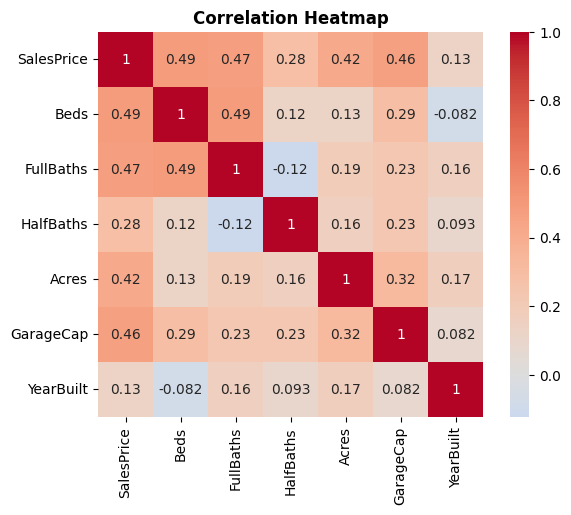

In [111]:
##  CORRELATION HEATMAP

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', center=0,square=True,)
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')


plt.show()

Correlation: 0.48920785131375943


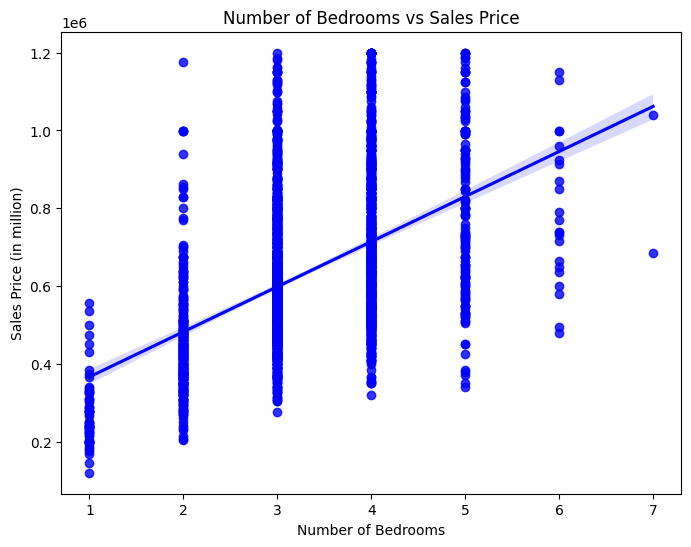

In [112]:
## Bedrooms vs Price

bedrooms_price = df[['Beds', 'SalesPrice']]

## Calculating correlation
corr_matrix = df['Beds'].corr(df['SalesPrice'])
print("Correlation:", corr_matrix)

## scatter plot
plt.figure(figsize=(8,6))

sns.regplot(data=df, x="Beds", y="SalesPrice", color='b')

plt.title(f"Number of Bedrooms vs Sales Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sales Price (in million)")

plt.show()

In [113]:
print(df["Town"].unique())

[2904 2908 2912 2916 2920 2903 2907 2911 2915 2919 2901 2902 2905 2906
 2909 2910 2913 2914 2917 2918]


In [114]:
## There are astrik in town columns

df['Town'] = (df['Town'].astype(str)  .str.replace('*', '').str.strip())
df.head(5)

,SalesPrice,Beds,Acres,GarageCap,YearBuilt,Town,ZipCode,Style_short,FullBaths,HalfBaths
0,550000.0,4.0,0.15,2.0,1915.0,2904,07208,"Colonial,",1,1
2,195000.0,1.0,0.19,1.0,1953.0,2904,07202,"SeeRem,MultiFlr,OneFloor",1,0
3,198000.0,1.0,0.19,0.0,2007.0,2904,07202,"OneFloor,",1,0
4,226000.0,1.0,0.04,0.0,1967.0,2904,07208,"OneFloor,",1,0
5,200000.0,1.0,0.19,0.0,2007.0,2904,07202,"OneFloor,",1,0


In [115]:
print("Checking for missing values :")
print(df.isnull().sum())
df=df.dropna()

print(df["Town"].unique())

print(df.shape)

Checking for missing values :
SalesPrice     0
Beds           0
Acres          0
GarageCap      0
YearBuilt      0
Town           0
ZipCode        0
Style_short    0
FullBaths      0
HalfBaths      0
dtype: int64
['2904' '2908' '2912' '2916' '2920' '2903' '2907' '2911' '2915' '2919'
 '2901' '2902' '2905' '2906' '2909' '2910' '2913' '2914' '2917' '2918']
(2487, 10)


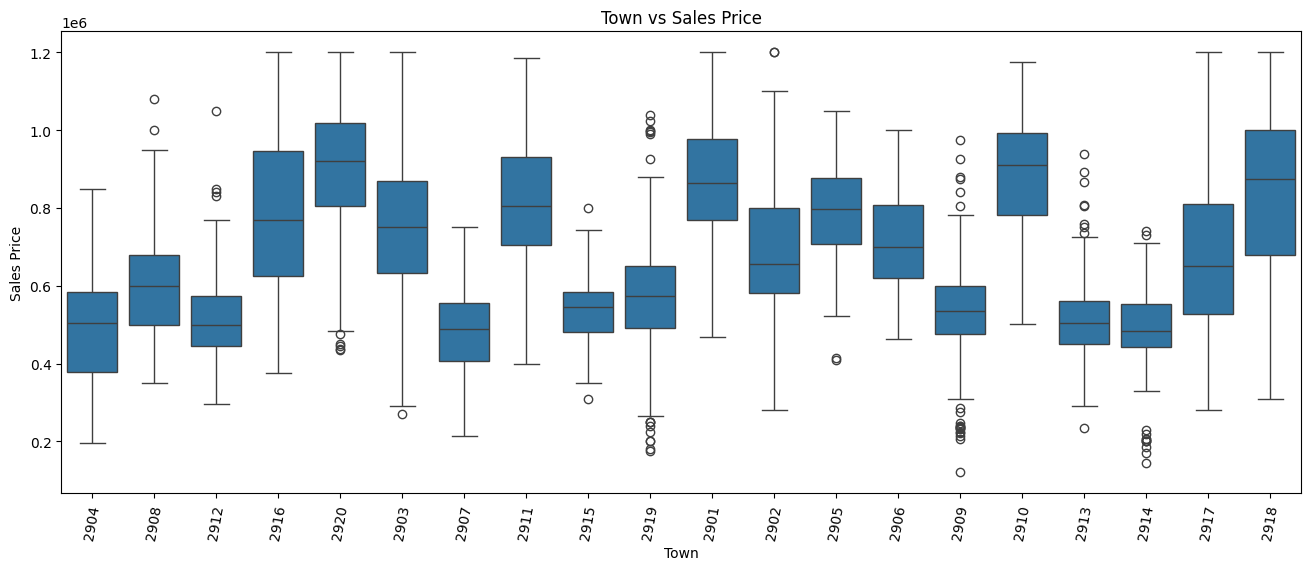

In [116]:
# Town vs Sales Price graph

plt.figure(figsize=(16,6))

# Showing top 20 towns to make it clean and clear

top_towns = df['Town'].value_counts().head(100).index
df_filtered = df[df['Town'].isin(top_towns)]

sns.boxplot(data=df_filtered, x='Town', y='SalesPrice')
plt.title('Town vs Sales Price')
plt.xlabel('Town')
plt.ylabel('Sales Price')

plt.xticks(rotation=80)

plt.show()

In [117]:
df.to_csv('Model_Training.csv', index=False)